[1 2 3 4 5 6]
K 6  np.mean(ith_cluster_silhouette_values) 0.13822145844839234 str(i) 1 
K 6  np.mean(ith_cluster_silhouette_values) 0.18843231272539346 str(i) 2 
K 6  np.mean(ith_cluster_silhouette_values) 0.12388078792568528 str(i) 3 
K 6  np.mean(ith_cluster_silhouette_values) 0.17080244462540092 str(i) 4 
K 6  np.mean(ith_cluster_silhouette_values) 0.2459358825191873 str(i) 5 
K 6  np.mean(ith_cluster_silhouette_values) 0.12897338870951017 str(i) 6 
[1 2 3 4 5 6 7]
K 7  np.mean(ith_cluster_silhouette_values) 0.1619950784431216 str(i) 1 
K 7  np.mean(ith_cluster_silhouette_values) 0.12686092027517668 str(i) 2 
K 7  np.mean(ith_cluster_silhouette_values) 0.16027465967556537 str(i) 3 
K 7  np.mean(ith_cluster_silhouette_values) 0.1741102524094952 str(i) 4 
K 7  np.mean(ith_cluster_silhouette_values) 0.10520350791466176 str(i) 5 
K 7  np.mean(ith_cluster_silhouette_values) 0.24750625613481458 str(i) 6 
K 7  np.mean(ith_cluster_silhouette_values) 0.12618258974246596 str(i) 7 
[1 2 3 4 5 

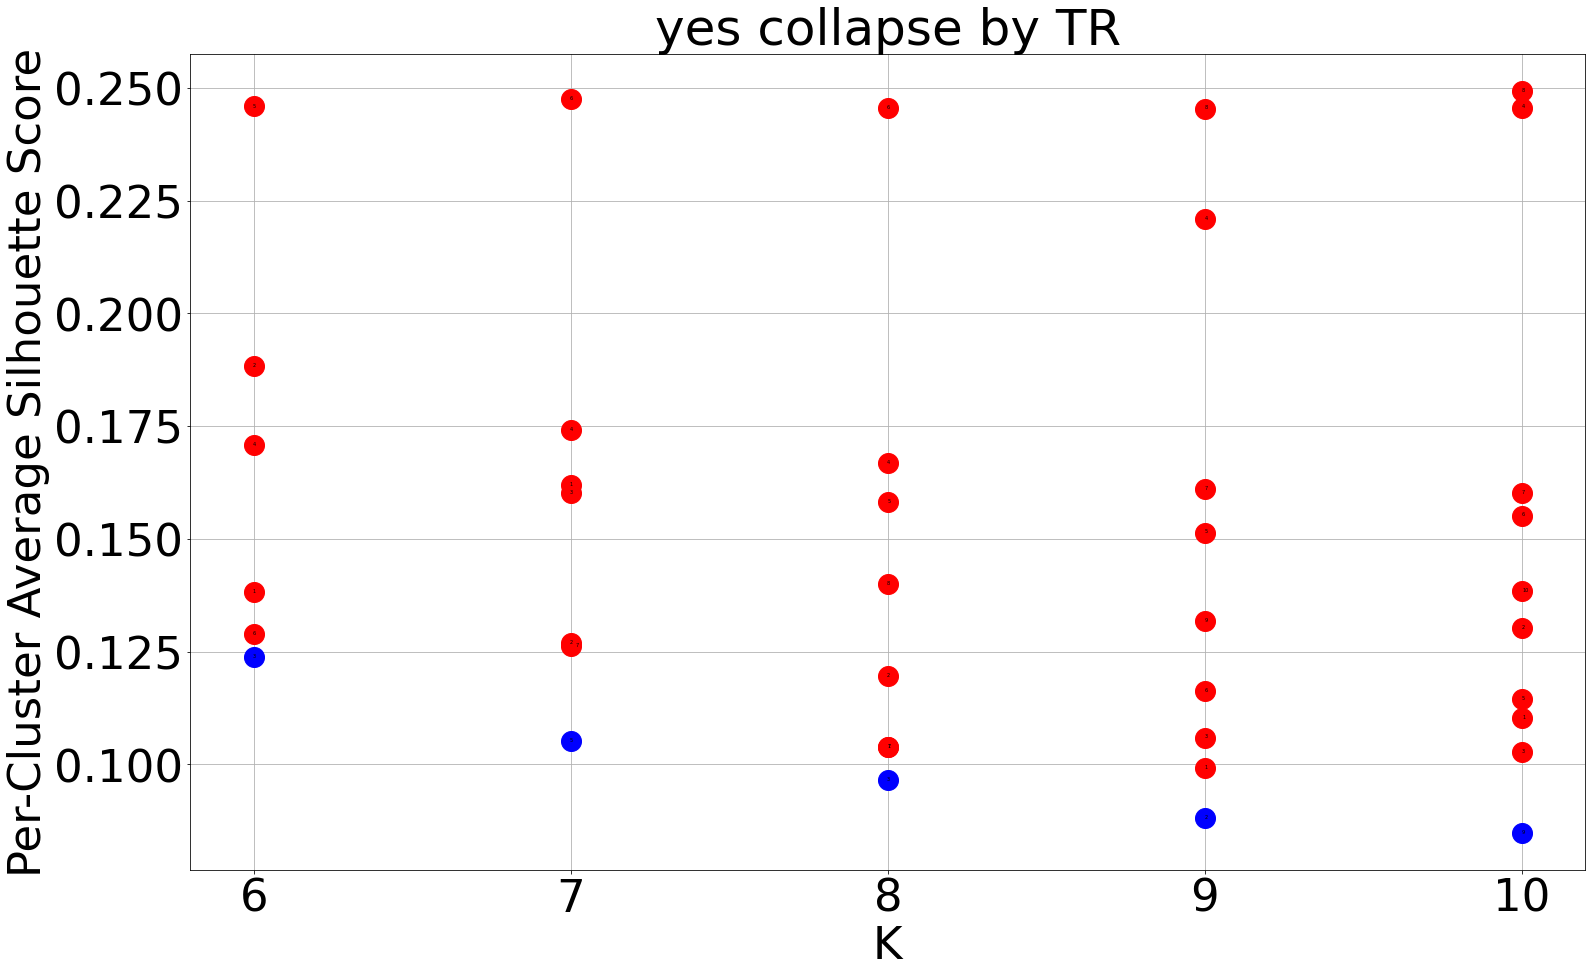

In [5]:
import pdb
import copy
import numpy as np
import matplotlib.cm as cm
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
import matplotlib
from sklearn.metrics import silhouette_samples, silhouette_score
import nibabel as nib
from nilearn import plotting
from nilearn import image
from nilearn import datasets, surface
import numpy as np
import os
import matplotlib.font_manager
plt.rcParams.update({'font.size': 16})
from adjustText import adjust_text


fig, (ax1) = plt.subplots(1, 1)
fig.set_size_inches(25, 15)
fsize = 45
ax1.set_xticks([i for i in range(4,11)])
ax1.set_xlabel("K", fontsize = fsize)
ax1.set_ylabel("Per-Cluster Average Silhouette Score", fontsize = fsize)
ax1.tick_params(axis='x', labelsize=fsize)
ax1.tick_params(axis='y', labelsize=fsize)
texts = []
for K in range(6,11):
    in_dir = "/scratch/gpfs/rk1593/clustering_output/kmeans_silhouette_tval_collapseTR/kmeans" + str(K) + "_silhouttes_collapseTR.csv"
    labels_dir = "/scratch/gpfs/rk1593/clustering_output/kmeans_assignments_tval_collapseTR/kmeans_" + str(K) + "clusters_collapseTR.csv"
    df = pd.read_csv(labels_dir)
    cluster_labels = np.array(df["cluster_assignment"].tolist())
    print(np.unique(cluster_labels))
    searchlight_np = np.array((df["searchlight"].tolist()))
    sample_silhouette_values = np.loadtxt(in_dir, delimiter = ",")
    n_clusters = K
    # get worst cluster index
    worst_cluster_avg = 200
    worst_cluster_i = -100
    for i in range(1,n_clusters + 1):    
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_avg = np.mean(ith_cluster_silhouette_values)
        if ith_cluster_avg < worst_cluster_avg:
            worst_cluster_avg = ith_cluster_avg
            worst_cluster_i = i
    for i in range(1,n_clusters + 1): 
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        if i == worst_cluster_i:
            ax1.plot(K,np.mean(ith_cluster_silhouette_values), 'bo', markersize = 20)
        else:
            ax1.plot(K ,np.mean(ith_cluster_silhouette_values), 'ro', markersize = 20)
        horizontal_offset = -0.05 if (i % 2) == 0 else 0.05 
        print(f"K {K}  np.mean(ith_cluster_silhouette_values) {np.mean(ith_cluster_silhouette_values)} str(i) {str(i)} ")
        texts.append(ax1.text(K,np.mean(ith_cluster_silhouette_values), str(i), size = 30))
    adjust_text(texts,only_move='x+')
    plt.title("yes collapse by TR", fontsize = 50)
    plt.grid()
    plt.savefig("silhouettes_labeled_cluster_avg.png")


In [ ]:
K 8  np.mean(ith_cluster_silhouette_values) 0.10378058318072038 str(i) 1 
K 8  np.mean(ith_cluster_silhouette_values) 0.1194852394752951 str(i) 2 
K 8  np.mean(ith_cluster_silhouette_values) 0.09647916884001718 str(i) 3 
K 8  np.mean(ith_cluster_silhouette_values) 0.16691025819288066 str(i) 4 
K 8  np.mean(ith_cluster_silhouette_values) 0.15823951768780317 str(i) 5 
K 8  np.mean(ith_cluster_silhouette_values) 0.2456232046850287 str(i) 6 
K 8  np.mean(ith_cluster_silhouette_values) 0.10373048949790122 str(i) 7 

In [7]:
0.10378058318072038 > 0.10373048949790122

True